<a href="https://colab.research.google.com/github/AxdKyn13/Projects-Trial/blob/main/Mini_Project_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library & Input Dataset

In [ ]:
#Import library
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

#Input train & test dataset
drive.mount('/content/drive')
d_train = pd.read_csv("/content/drive/MyDrive/Mini Project Deep Learning/MPDL_training.csv")
d_test = pd.read_csv("/content/drive/MyDrive/Mini Project Deep Learning/MPDL_testing.csv")

Mounted at /content/drive


Distribusi fitur

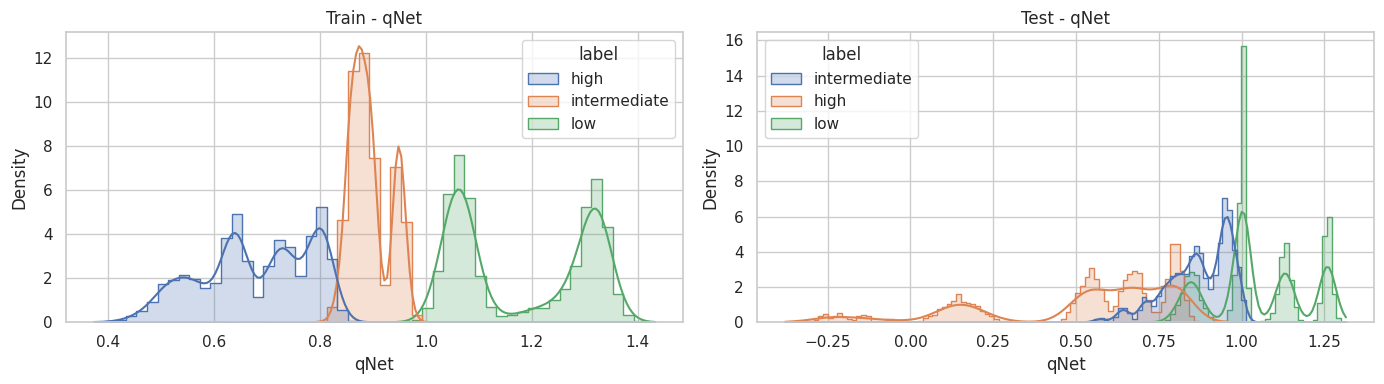

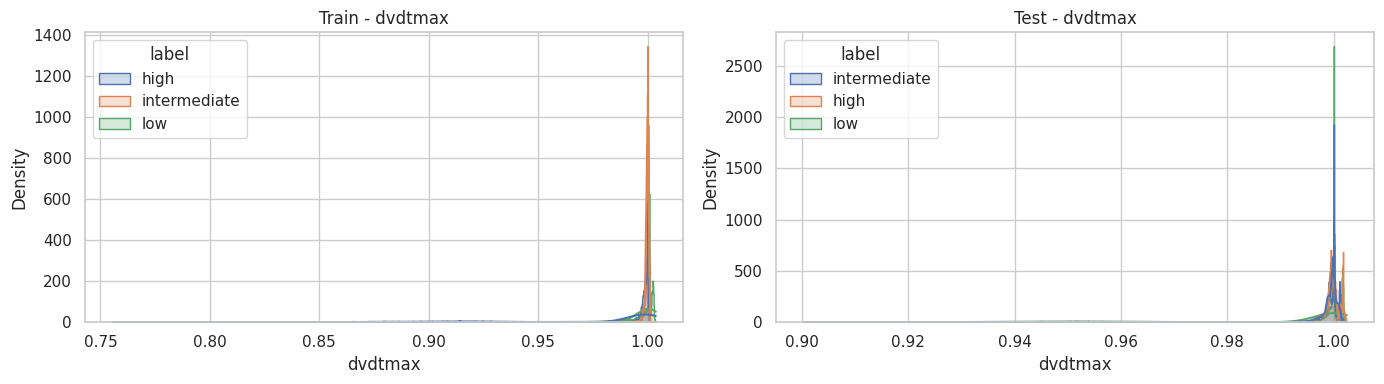

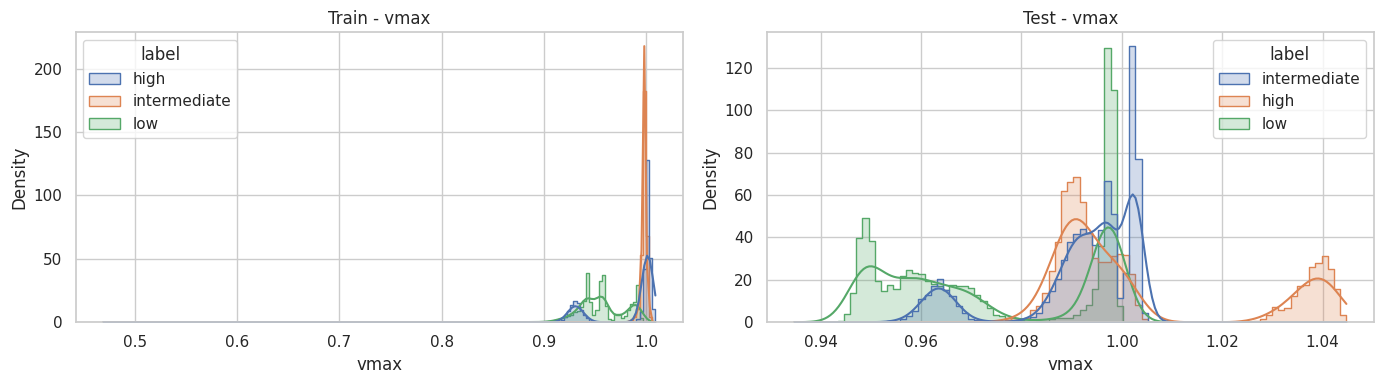

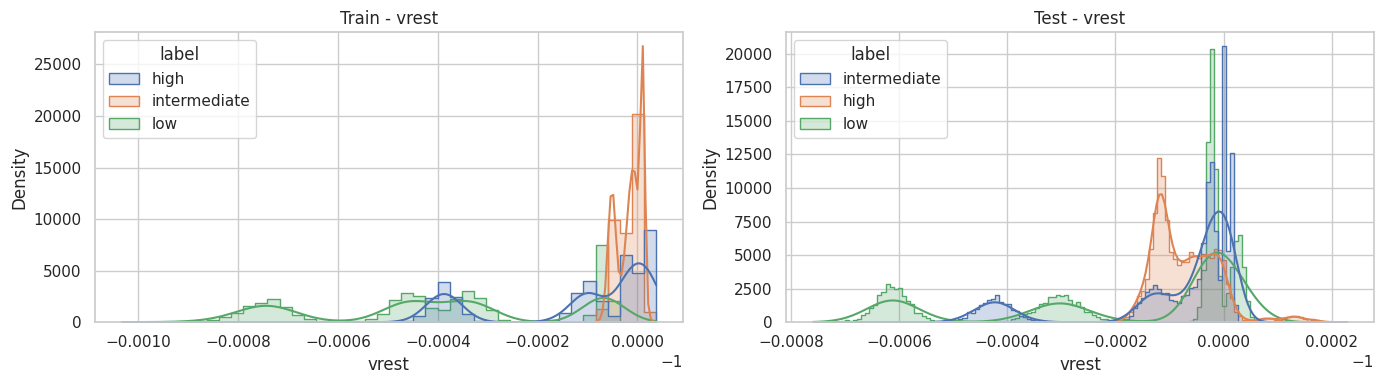

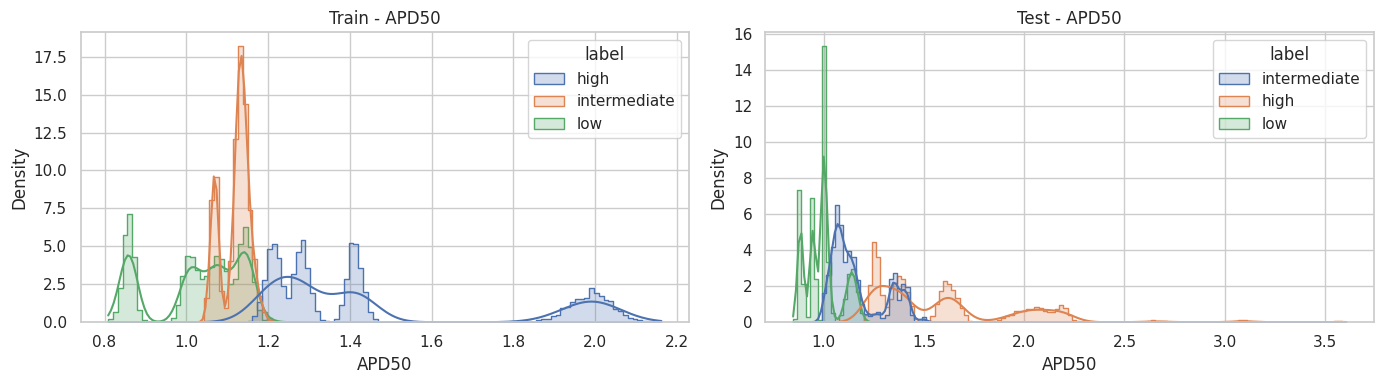

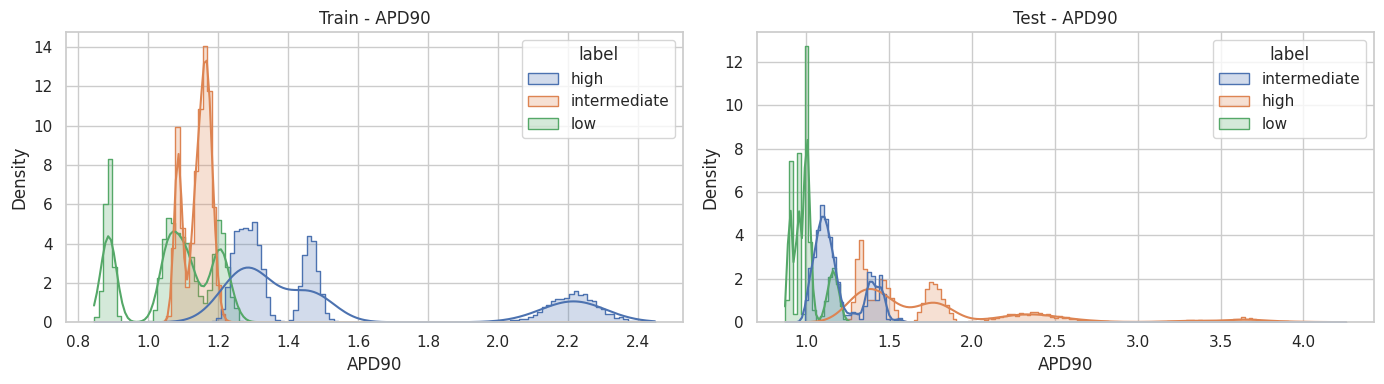

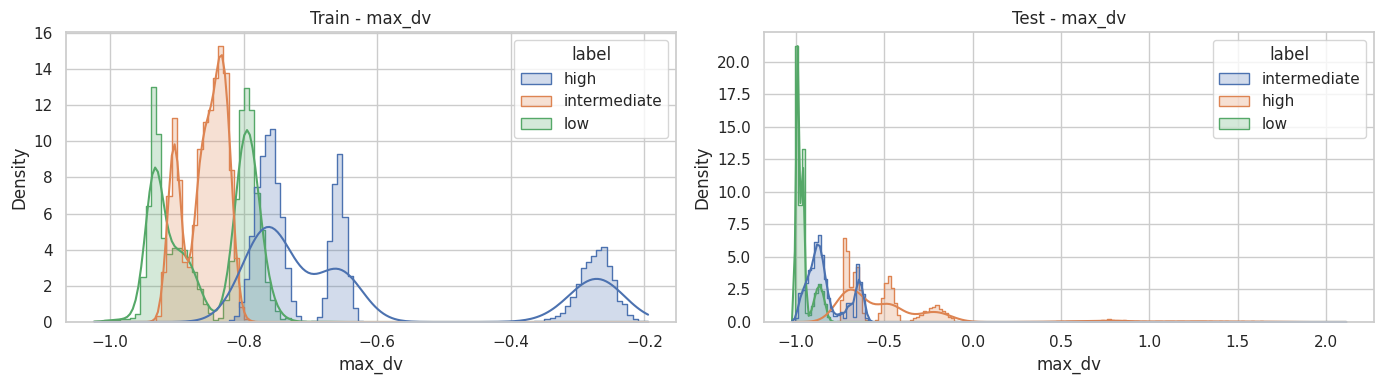

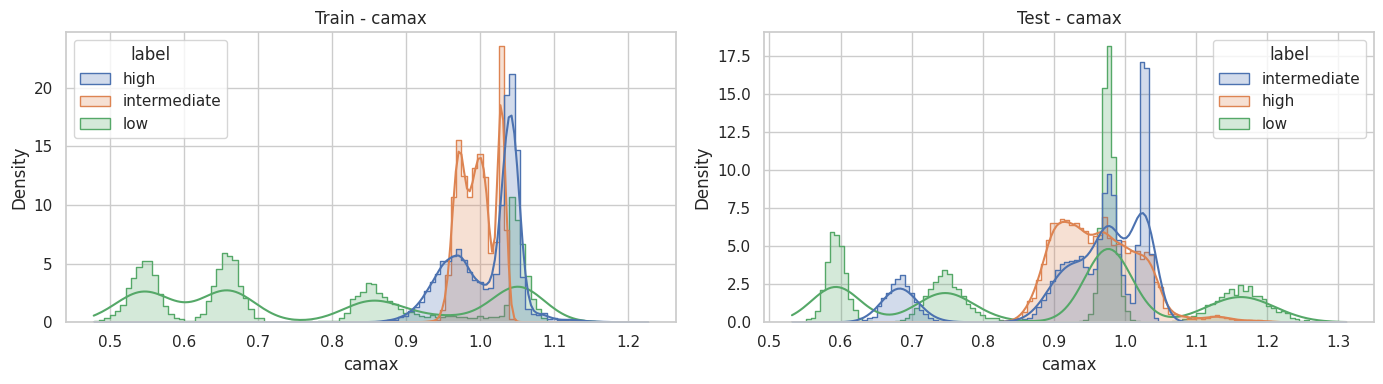

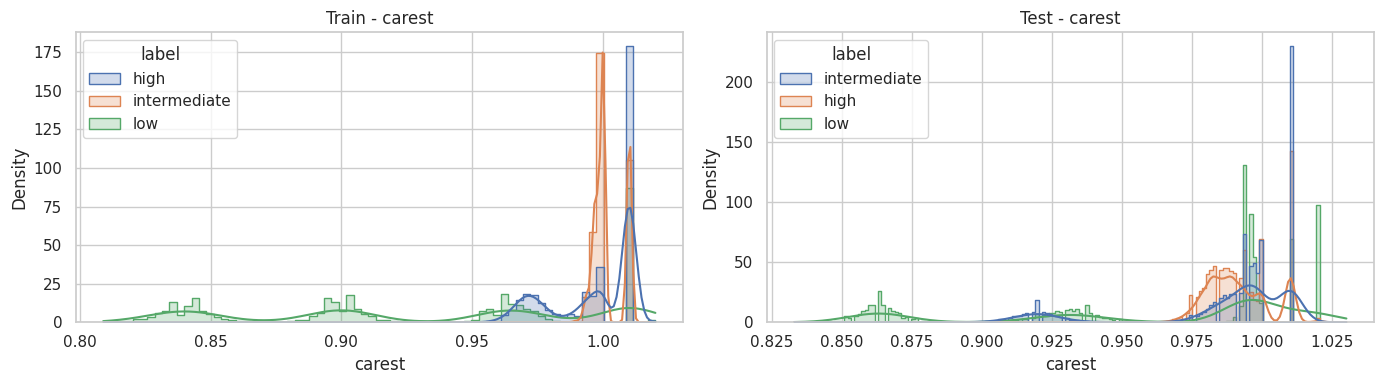

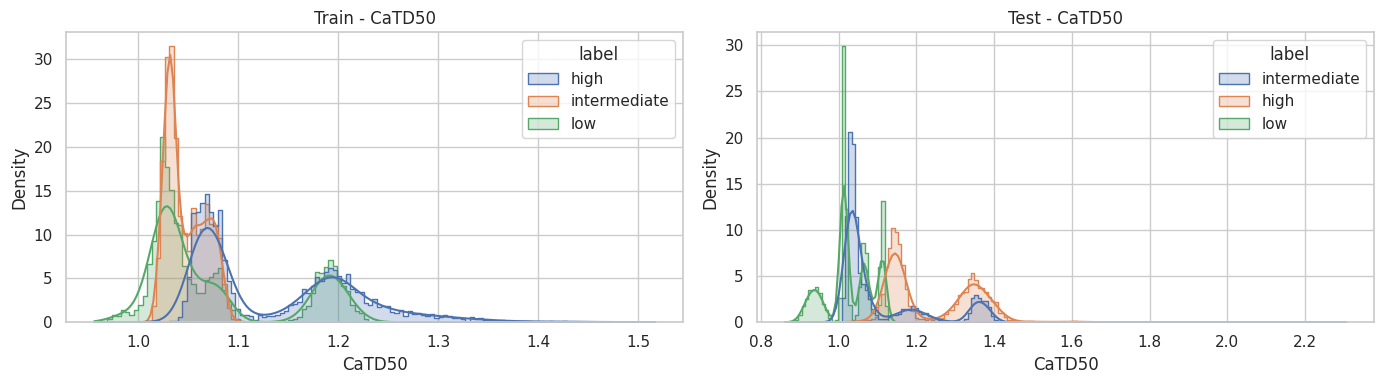

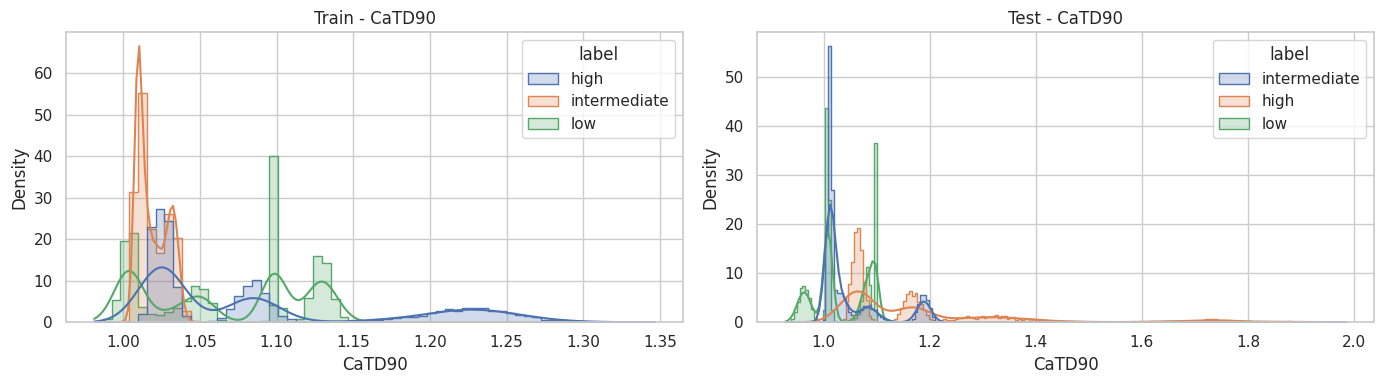

In [ ]:
# Drop columns that are not features
d_train_processed = d_train.drop(['drug_name', 'Sample_ID'], axis=1)
d_test_processed = d_test.drop(['drug_name', 'Sample_ID'], axis=1)

# label asli
y_train = d_train_processed['label']
y_test = d_test_processed['label']

# fitur
x_train = d_train_processed.drop('label', axis=1)
x_test = d_test_processed.drop('label', axis=1)

# convert numeric
x_train = x_train.apply(pd.to_numeric, errors='coerce')
x_test = x_test.apply(pd.to_numeric, errors='coerce')

# fill NaN with mean train
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_train.mean())

sns.set(style="whitegrid")

features = x_train.columns

for feature in features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ===== TRAIN =====
    sns.histplot(
        data=x_train.assign(label=y_train),
        x=feature,
        hue="label",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0]
    )
    axes[0].set_title(f"Train - {feature}")

    # ===== TEST =====
    sns.histplot(
        data=x_test.assign(label=y_test),
        x=feature,
        hue="label",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1]
    )
    axes[1].set_title(f"Test - {feature}")

    plt.tight_layout()
    plt.show()

Matriks korelasi

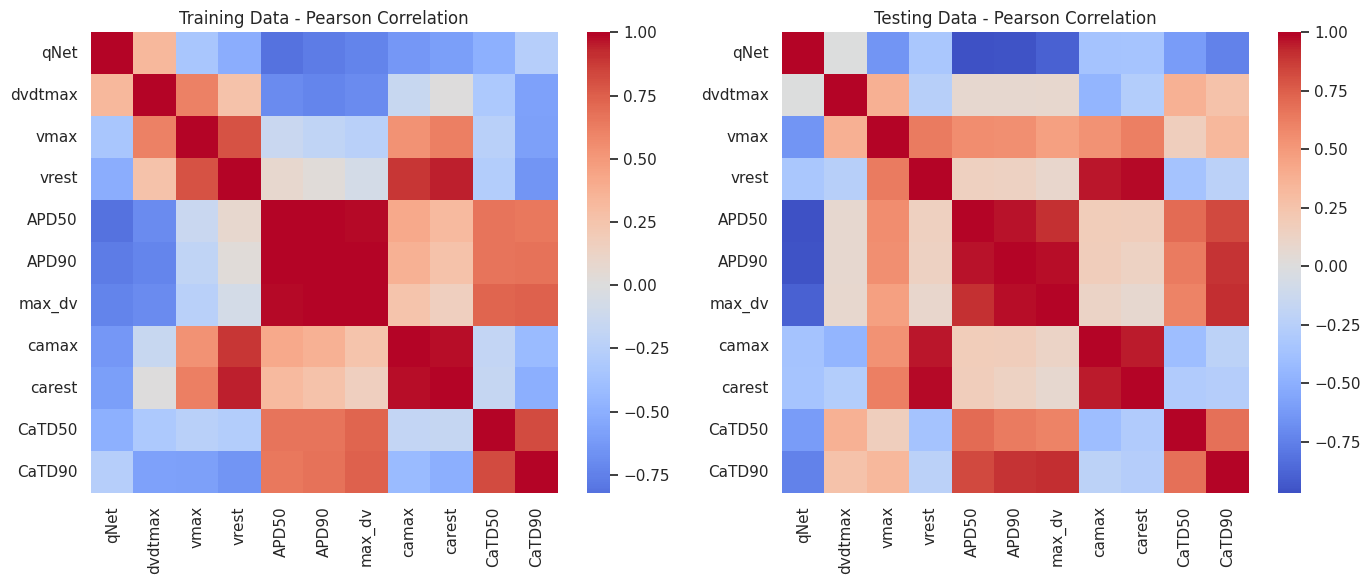

In [ ]:
plt.figure(figsize=(14,6))

# ===== TRAINING PEARSON CORRELATION =====
plt.subplot(1,2,1)
sns.heatmap(
    x_train.corr(method='pearson'),
    cmap='coolwarm',
    center=0
)
plt.title("Training Data - Pearson Correlation")

# ===== TESTING PEARSON CORRELATION =====
plt.subplot(1,2,2)
sns.heatmap(
    x_test.corr(method='pearson'),
    cmap='coolwarm',
    center=0
)
plt.title("Testing Data - Pearson Correlation")

plt.tight_layout()
plt.show()

Pre-Processing

In [ ]:
keras.utils.set_random_seed(42)

#Remove unused atribute
d_train = d_train.drop(['drug_name', 'Sample_ID'], axis=1)
d_test = d_test.drop(['drug_name', 'Sample_ID'], axis=1)

#Equalling data for binarize
low = d_train[d_train['label'] == 'low']
high = d_train[d_train['label'] == 'high']
intermediate = d_train[d_train['label'] == 'intermediate']

high_sample = high.sample(n=4000, random_state=42)
intermediate_sample = intermediate.sample(n=4000, random_state=42)

d_train = pd.concat([low, high_sample, intermediate_sample])

#Binarize
d_train['label'] = d_train['label'].map({
    'low': 0,
    'high': 1,
    'intermediate': 1
})
d_train = d_train.sample(frac=1, random_state=42).reset_index(drop=True)

d_test['label'] = d_test['label'].map({
    'low': 0,
    'high': 1,
    'intermediate': 1
})

#Define x & y
x_train = d_train.drop('label', axis=1)
y_train = d_train['label']
x_test = d_test.drop('label', axis=1)
y_test = d_test['label']

# Convert all columns in x_train and x_test to numeric, coercing errors (#VALUE -> NaN)
x_train = x_train.apply(pd.to_numeric, errors='coerce')
x_test = x_test.apply(pd.to_numeric, errors='coerce')

# Fill any NaN values that resulted from the coercion ('#VALUE!') to median
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_test.median()) # Use x_test's median for x_test

#Train-Validation splitting
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify = y_train)

#Download pre-processed dataset
d_train.to_csv('train_binary.csv', index=False)
d_test.to_csv('test_binary.csv', index=False)
d_train.to_csv('/content/drive/MyDrive/Mini Project Deep Learning/train_binary.csv', index=False)
d_test.to_csv('/content/drive/MyDrive/Mini Project Deep Learning/test_binary.csv', index=False)

ANN model (adam + no dropout)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8954 - loss: 0.4342 - val_accuracy: 0.9266 - val_loss: 0.2615
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9443 - loss: 0.1967 - val_accuracy: 0.9572 - val_loss: 0.1556
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.1231 - val_accuracy: 0.9859 - val_loss: 0.0999
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9934 - loss: 0.0778 - val_accuracy: 0.9956 - val_loss: 0.0622
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9977 - loss: 0.0481 - val_accuracy: 0.9981 - val_loss: 0.0384
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9991 - loss: 0.0297 - val_accuracy: 0.9994 - val_loss: 0.0241
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9996 - loss: 0.0187 - val_accuracy: 0.9997 - val_loss: 0.0155
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0121 - val_accuracy: 1.

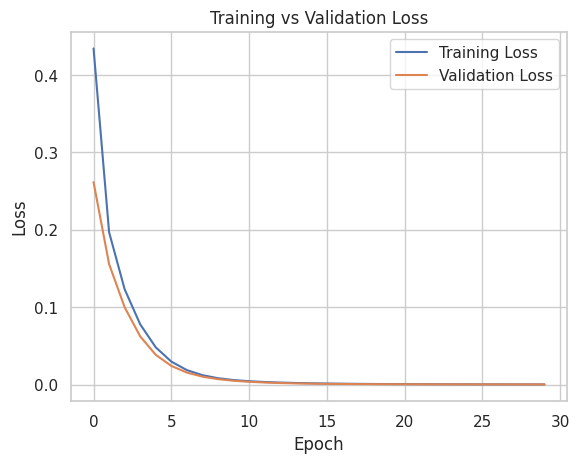

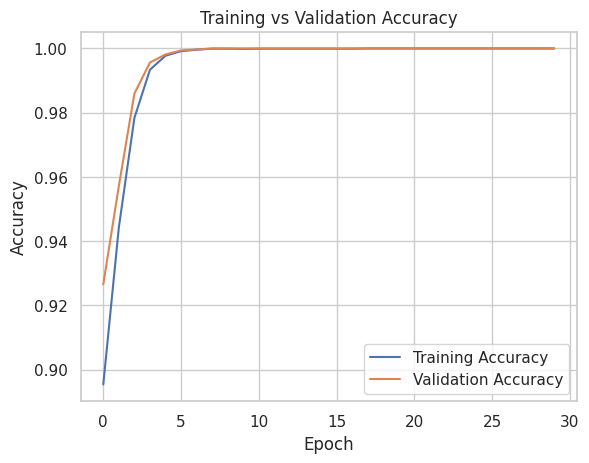

Accuracy: 0.809125
Precision: 0.7848437051907083
Recall: 0.9951818181818182
F1-score: 0.8775853775853776


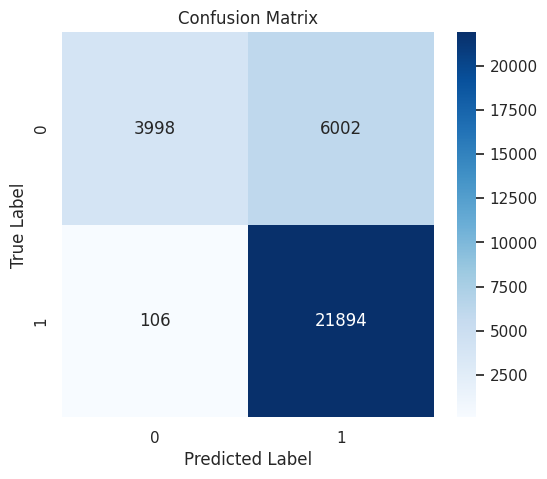

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
AUC Score: 0.8626392431818182


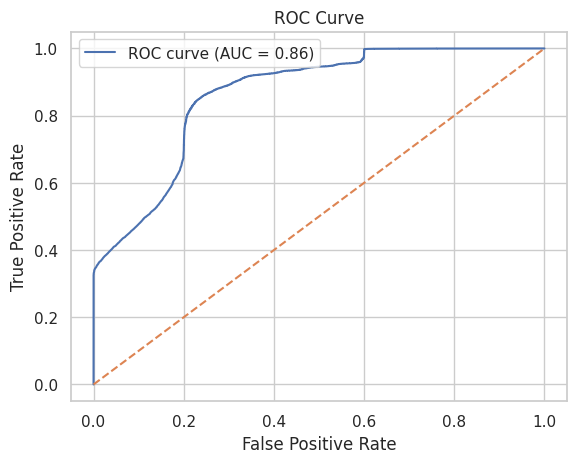

In [ ]:
#ANN model
num_columns = x_train.shape[1]
input = keras.Input(shape=(num_columns,))
h = keras.layers.Dense(16, activation="relu", name="Hidden_1")(input)

h = keras.layers.Dense(8, activation="relu", name="Hidden_2")(h)

output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(inputs=input, outputs=output)

#ANN training
model.compile(optimizer = "adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model_train = model.fit(x_train,
                    y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(x_val, y_val)
                    )

#Predict
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

#Train & validation loss plot
plt.figure()
plt.plot(model_train.history['loss'], label='Training Loss')
plt.plot(model_train.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#Train & validation accuracy plot
plt.figure()
plt.plot(model_train.history['accuracy'], label='Training Accuracy')
plt.plot(model_train.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

#Evaluation (Accuracy, precision, recall, F1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

#ROC & AUC score
y_prob = model.predict(x_test)
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % auc_score)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ANN model (adam + dropout)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6262 - loss: 0.6770 - val_accuracy: 0.8334 - val_loss: 0.5319
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7849 - loss: 0.4915 - val_accuracy: 0.8869 - val_loss: 0.3820
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.3869 - val_accuracy: 0.9119 - val_loss: 0.2875
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8648 - loss: 0.3177 - val_accuracy: 0.9303 - val_loss: 0.1911
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8954 - loss: 0.2515 - val_accuracy: 0.9638 - val_loss: 0.1398
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9191 - loss: 0.1999 - val_accuracy: 0.9878 - val_loss: 0.0906
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9334 - loss: 0.1717 - val_accuracy: 0.9953 - val_loss: 0.0643
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9441 - loss: 0.1441 - val_accuracy: 0.

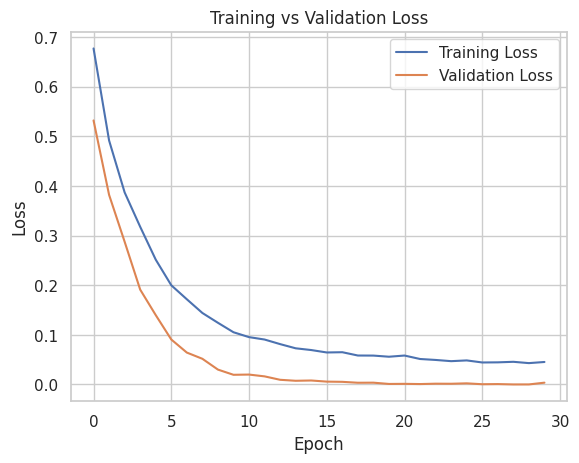

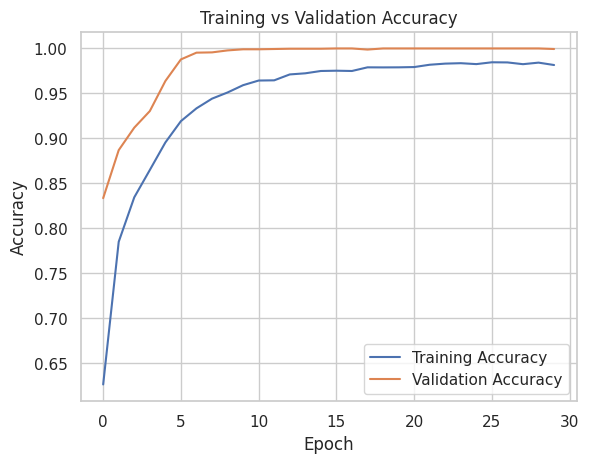

Accuracy: 0.837125
Precision: 0.8340496657115568
Recall: 0.9526363636363636
F1-score: 0.8894075708708199


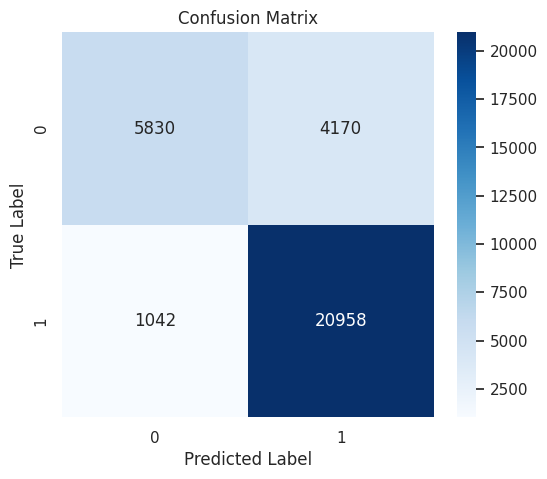

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
AUC Score: 0.8513505772727272


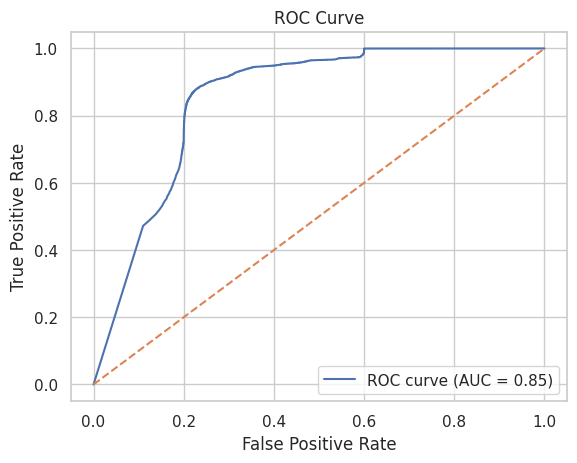

In [ ]:
#ANN model
num_columns = x_train.shape[1]
input = keras.Input(shape=(num_columns,))
h = keras.layers.Dense(16, activation="relu", name="Hidden_1")(input)
h = keras.layers.Dropout(0.3)(h)

h = keras.layers.Dense(8, activation="relu", name="Hidden_2")(h)
h = keras.layers.Dropout(0.3)(h)

output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(inputs=input, outputs=output)

#ANN training
model.compile(optimizer = "adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model_train = model.fit(x_train,
                    y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(x_val, y_val)
                    )

#Predict
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

#Train & validation loss plot
plt.figure()
plt.plot(model_train.history['loss'], label='Training Loss')
plt.plot(model_train.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#Train & validation accuracy plot
plt.figure()
plt.plot(model_train.history['accuracy'], label='Training Accuracy')
plt.plot(model_train.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

#Evaluation (Accuracy, precision, recall, F1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

#ROC & AUC score
y_prob = model.predict(x_test)
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % auc_score)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ANN model (SGD + dropout)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5623 - loss: 0.6826 - val_accuracy: 0.6950 - val_loss: 0.6273
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6498 - loss: 0.6265 - val_accuracy: 0.8278 - val_loss: 0.5523
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7342 - loss: 0.5553 - val_accuracy: 0.9112 - val_loss: 0.4603
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7864 - loss: 0.4829 - val_accuracy: 0.9212 - val_loss: 0.3789
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8205 - loss: 0.4201 - val_accuracy: 0.9359 - val_loss: 0.3042
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8431 - loss: 0.3673 - val_accuracy: 0.9547 - val_loss: 0.2533
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8754 - loss: 0.3132 - val_accuracy: 0.9634 - val_loss: 0.2049
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8955 - loss: 0.2736 - val_accuracy: 0.

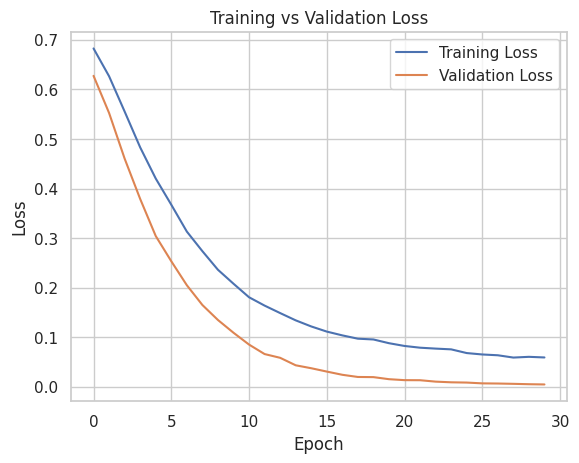

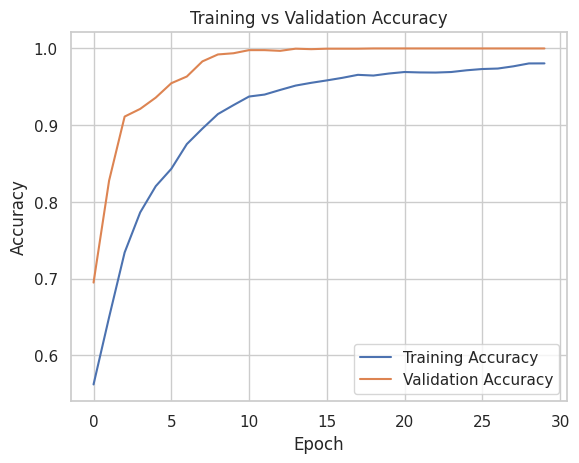

Accuracy: 0.8069375
Precision: 0.7843842116615142
Recall: 0.9918181818181818
F1-score: 0.8759885984985347


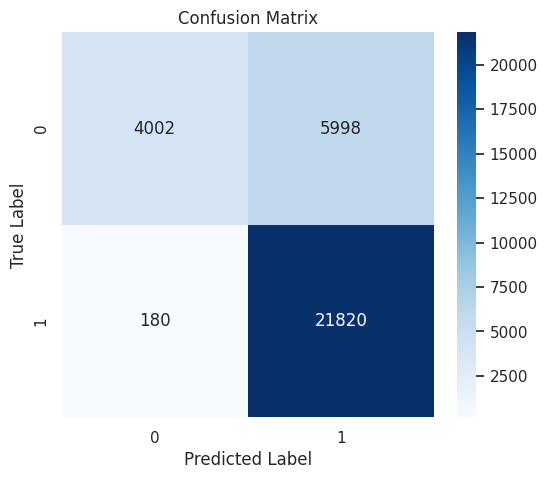

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
AUC Score: 0.8778408522727273


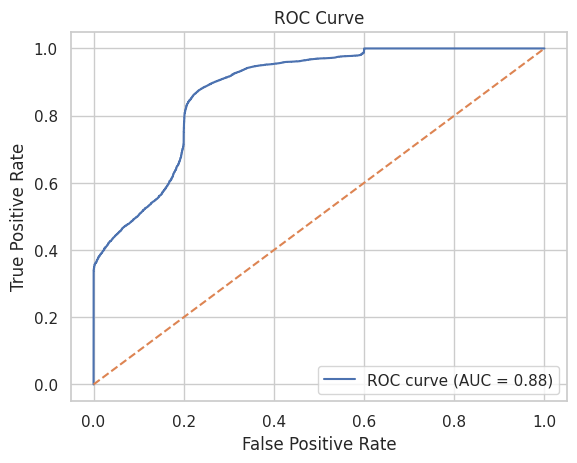

In [ ]:
#ANN model
num_columns = x_train.shape[1]
input = keras.Input(shape=(num_columns,))
h = keras.layers.Dense(16, activation="relu", name="Hidden_1")(input)
h = keras.layers.Dropout(0.3)(h)

h = keras.layers.Dense(8, activation="relu", name="Hidden_2")(h)
h = keras.layers.Dropout(0.3)(h)

output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(inputs=input, outputs=output)

#ANN training
model.compile(optimizer="sgd",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model_train = model.fit(x_train,
                    y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(x_val, y_val)
                    )

#Predict
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

#Train & validation loss plot
plt.figure()
plt.plot(model_train.history['loss'], label='Training Loss')
plt.plot(model_train.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#Train & validation accuracy plot
plt.figure()
plt.plot(model_train.history['accuracy'], label='Training Accuracy')
plt.plot(model_train.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

#Evaluation (Accuracy, precision, recall, F1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

#ROC & AUC score
y_prob = model.predict(x_test)
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % auc_score)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()